## 01 — Data Understanding & Structural Inspection

### Objective

Before modeling corporate bankruptcy risk, we first perform a detailed structural examination of the dataset.

This notebook aims to:

1. Understand dataset composition and dimensionality.
2. Inspect class imbalance across horizons.
3. Identify missing values.
4. Examine distributional skewness and outliers.
5. Quantify extreme value behavior using percentiles.
6. Establish foundational understanding of financial ratio behavior.

---

### Dataset Description

- 64 engineered financial ratios per firm.
- Binary target variable: `class`
    - 0 → Non-bankrupt
    - 1 → Bankrupt
- Severe class imbalance (~3–7% bankruptcy rate depending on horizon).
- Ratios include profitability, leverage, liquidity, efficiency, and cash-flow measures.

---

### Why This Step Matters

Financial data is typically:

- Heavy-tailed
- Skewed
- Contaminated with extreme outliers
- Structurally imbalanced

Blind modeling without inspection leads to:

- Inflated variance
- Poor calibration
- Unstable coefficients
- Misleading thresholds

Therefore, we first study the statistical and structural properties of the dataset.

In [ ]:
from scipy.io import arff
import pandas as pd

data, meta = arff.loadarff("../data/raw/1year.arff")
df = pd.DataFrame(data)

df.shape

(7027, 65)

In [13]:
df.columns

Index(['Attr1', 'Attr2', 'Attr3', 'Attr4', 'Attr5', 'Attr6', 'Attr7', 'Attr8',
       'Attr9', 'Attr10', 'Attr11', 'Attr12', 'Attr13', 'Attr14', 'Attr15',
       'Attr16', 'Attr17', 'Attr18', 'Attr19', 'Attr20', 'Attr21', 'Attr22',
       'Attr23', 'Attr24', 'Attr25', 'Attr26', 'Attr27', 'Attr28', 'Attr29',
       'Attr30', 'Attr31', 'Attr32', 'Attr33', 'Attr34', 'Attr35', 'Attr36',
       'Attr37', 'Attr38', 'Attr39', 'Attr40', 'Attr41', 'Attr42', 'Attr43',
       'Attr44', 'Attr45', 'Attr46', 'Attr47', 'Attr48', 'Attr49', 'Attr50',
       'Attr51', 'Attr52', 'Attr53', 'Attr54', 'Attr55', 'Attr56', 'Attr57',
       'Attr58', 'Attr59', 'Attr60', 'Attr61', 'Attr62', 'Attr63', 'Attr64',
       'class'],
      dtype='object')

In [3]:
df['class'].value_counts()

class
b'0'    6756
b'1'     271
Name: count, dtype: int64

In [4]:
df['class'] = df['class'].apply(lambda x: int(x.decode('utf-8')))
df['class'].value_counts()

class
0    6756
1     271
Name: count, dtype: int64

In [8]:
df.isnull().sum().sum()

np.int64(5835)

In [9]:
total_cells = df.shape[0] * df.shape[1]
missing_percentage = 5835 / total_cells
missing_percentage

0.012774901205241322

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Attr1,7024.0,0.034660,4.565504,-2.568900e+02,0.021182,0.075802,0.160268,94.28
Attr2,7024.0,0.560215,5.350084,-7.216200e+01,0.296678,0.482960,0.680233,441.50
Attr3,7024.0,0.119969,5.275459,-4.405000e+02,0.026968,0.181275,0.362548,1.00
Attr4,6997.0,2.629143,13.257356,0.000000e+00,1.063100,1.502000,2.460700,1017.80
Attr5,7019.0,-263.167247,37074.596449,-2.722100e+06,-44.498000,-5.373900,37.770500,990900.00
...,...,...,...,...,...,...,...,...
Attr61,7005.0,15.642228,261.554534,1.600000e-05,4.829000,7.033700,10.703000,21110.00
Attr62,7027.0,4763.201955,310783.483587,0.000000e+00,43.222500,68.509000,106.335000,25016000.00
Attr63,6997.0,8.126852,19.996419,1.500000e-05,3.425400,5.303200,8.357900,1042.20
Attr64,6993.0,208.731950,5140.708804,1.000000e-05,2.538600,4.637700,9.782200,294770.00


In [15]:
df.skew().sort_values(ascending=False).head(10)

Attr58    83.827153
Attr20    83.825791
Attr43    83.713893
Attr44    83.634487
Attr30    83.384272
Attr51    83.067834
Attr13    82.534802
Attr60    79.847212
Attr2     79.390079
Attr62    76.030741
dtype: float64

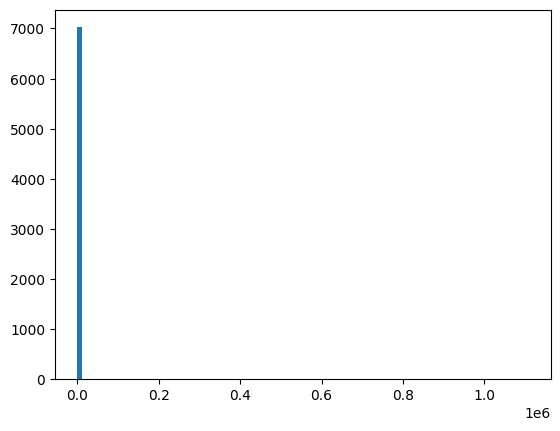

In [16]:
import matplotlib.pyplot as plt

plt.hist(df["Attr58"], bins=100)
plt.show()

In [18]:
df["Attr58"].quantile(0.99)

np.float64(1.233696)

In [20]:
df["Attr58"].max()

np.float64(1108300.0)

In [22]:
skewed_features = df.skew().abs() > 10
skewed_features.sum()

np.int64(63)

## 📌 Observations & Structural Insights

### 1️⃣ Severe Class Imbalance

- Bankruptcy rate ranges from ~3.86% to ~6.94%.
- Default threshold of 0.5 is inappropriate.
- Cost-sensitive modeling is necessary.

---

### 2️⃣ Heavy Right-Skew & Extreme Outliers

- Many financial ratios exhibit extreme maxima relative to 99th percentile.
- Example:
    - 99th percentile ≈ 1.23
    - Maximum ≈ 1,108,300

This indicates:

- Heavy-tailed distribution
- Potential accounting anomalies
- High variance leverage in modeling

Winsorization or robust scaling may be required.

---

### 3️⃣ Missing Values

- Several ratios contain missing entries.
- Imputation strategy: Median imputation (robust to skew).

---

### 4️⃣ Financial Ratios Are Non-Normal

Most variables show:

- Skewness
- Long tails
- Concentration near zero

Linear assumptions may not fully capture interactions.

---

### 5️⃣ Structural Takeaway

Corporate financial distress data is:

- Noisy
- Imbalanced
- Heavy-tailed
- Economically complex

This justifies:

- Regularization
- Nonlinear modeling
- Cost-sensitive optimization
- Careful threshold selection

This notebook establishes the statistical foundation for all subsequent modeling.